In [1]:
import numpy as np 
import pandas as pd
import os

dir_csv = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
df_train = pd.read_csv(os.path.join(dir_csv,"Train.csv"))
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [2]:
gtsrb_classes = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5 metric tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5 metric tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5 metric tons'
}

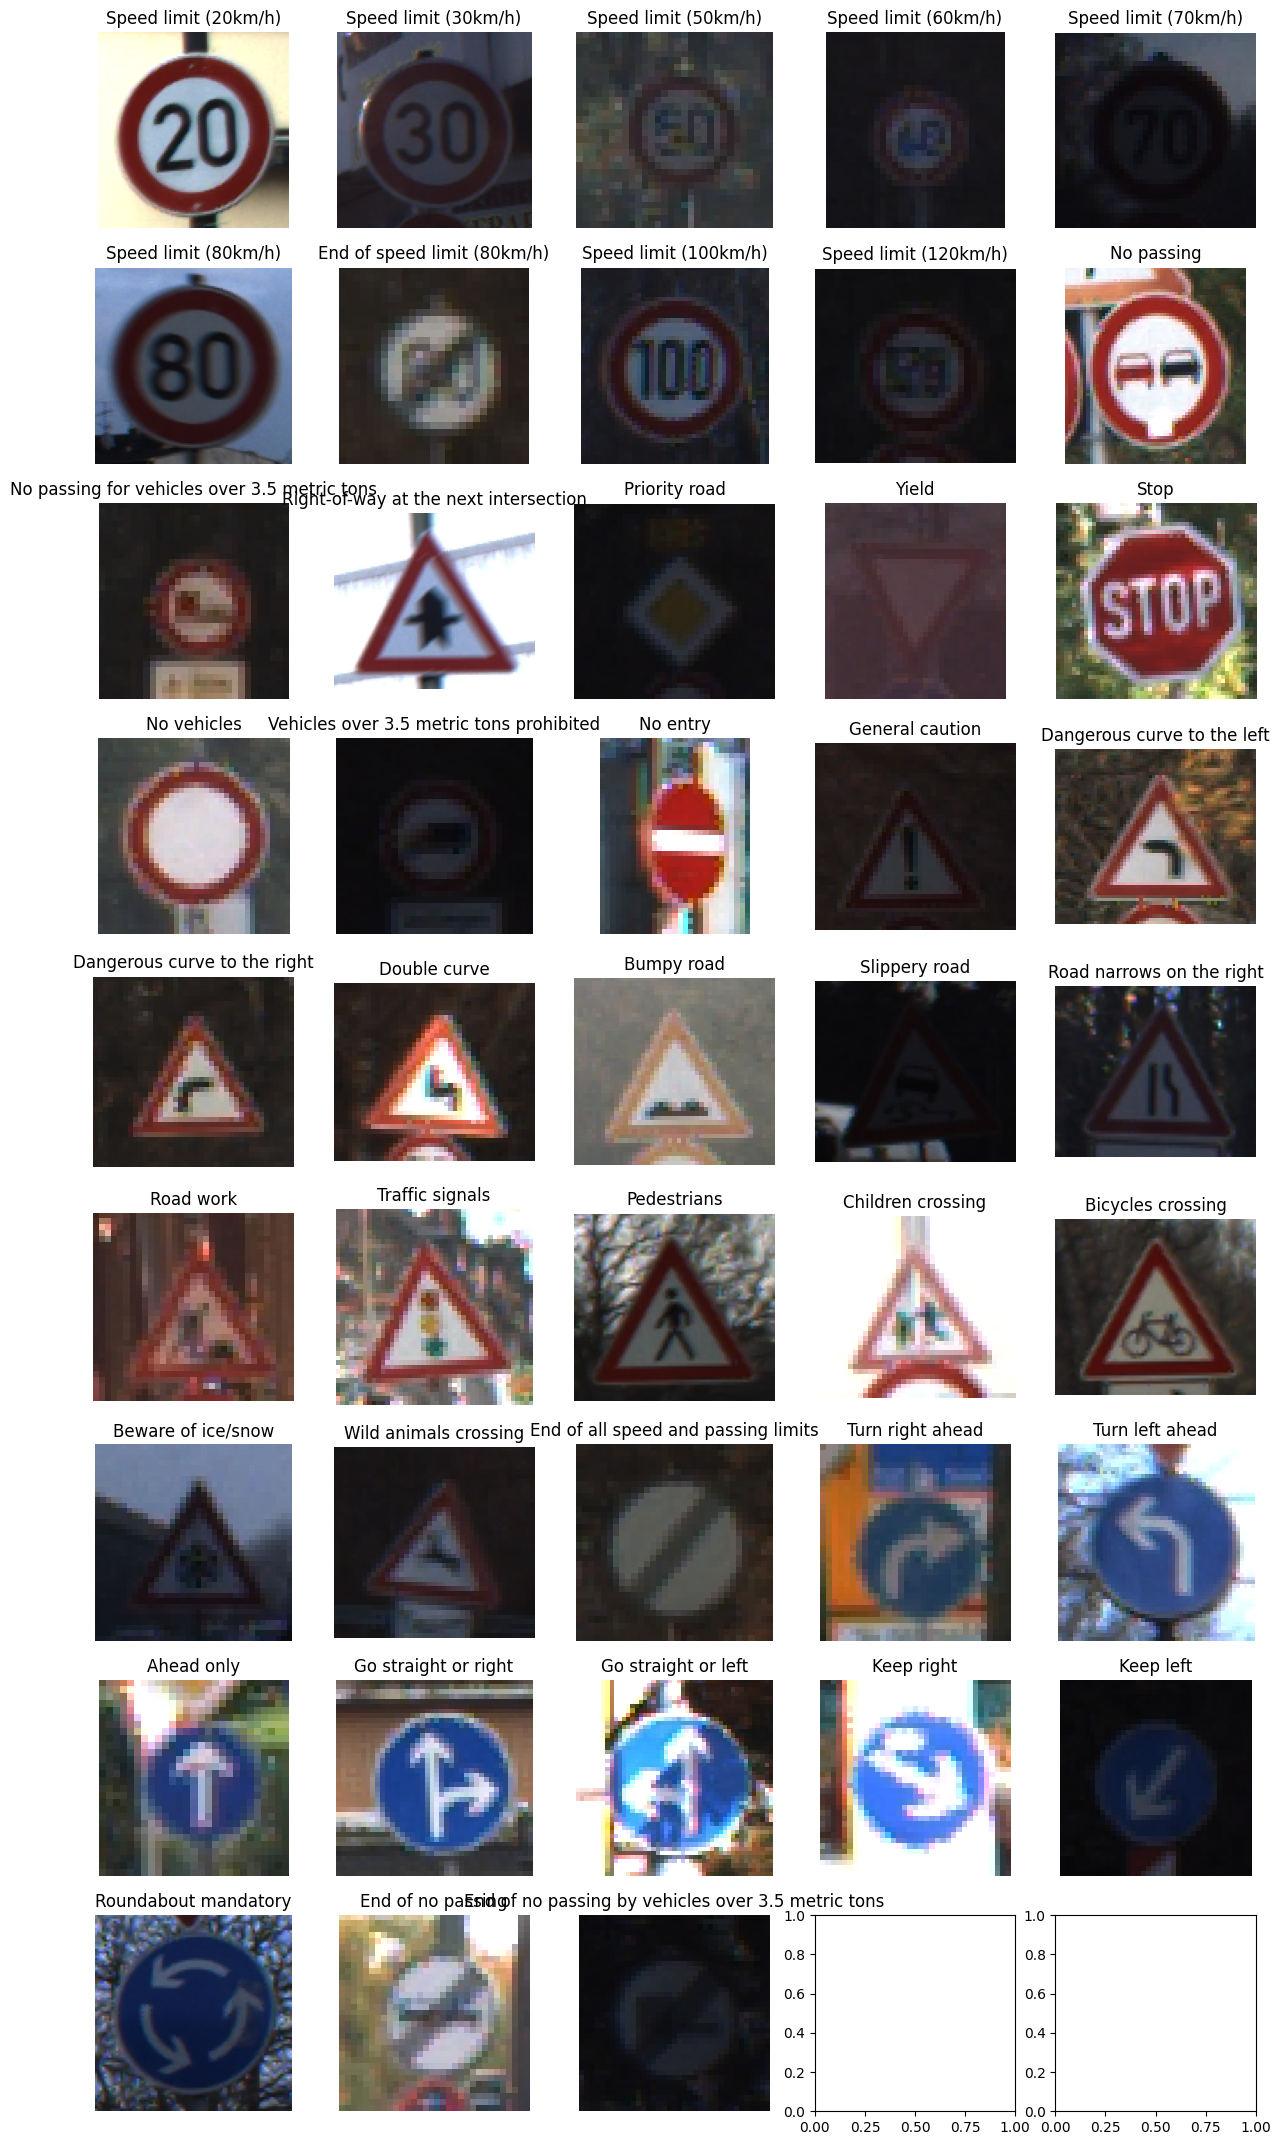

In [3]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

class_list = list(range(0,43))


cols = 5
rows = math.ceil(len(class_list) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()
valid_ext = ('.png', '.jpg', '.jpeg', '.ppm', '.bmp')
train_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'
for i in class_list:
    class_dir = os.path.join(train_dir,str(i))
    first_image = None
    files = os.listdir(class_dir)
    
    # Search First File
    for file in files:
        if file.lower().endswith(valid_ext):
            first_image = file
            break
    img_path = os.path.join(class_dir, file)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(gtsrb_classes[i])
    axes[i].axis('off')


    
    

# For This Project We Only Use Some Labels Only

In [4]:
Label_name = gtsrb_classes = {
    0: 'Speed limit (20km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    14: 'Stop',
    17: 'No entry',
    27: 'Pedestrians',
    35: 'Ahead only'
}
Label = [0,7,8,14,17,27,35]

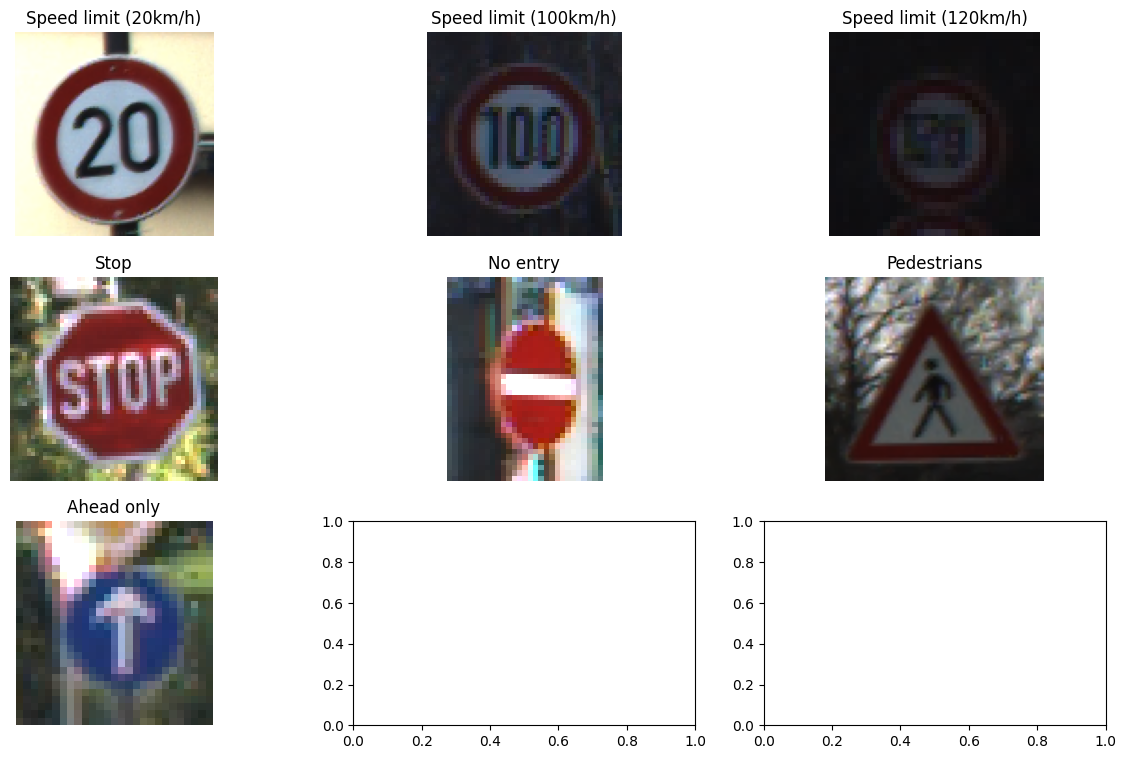

In [5]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image



cols = 3
rows = math.ceil(len(Label) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()
valid_ext = ('.png', '.jpg', '.jpeg', '.ppm', '.bmp')
train_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'
for idx,i in enumerate(Label):
    class_dir = os.path.join(train_dir,str(i))
    first_image = None
    files = os.listdir(class_dir)
    
    # Search First File
    for file in files:
        if file.lower().endswith(valid_ext):
            first_image = file
            break
    img_path = os.path.join(class_dir, file)
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(Label_name[i])
    axes[idx].axis('off')


    
    

In [6]:
import numpy as np 
import pandas as pd
import os

dir_csv = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
df_train = pd.read_csv(os.path.join(dir_csv,"Train.csv"))
df_train= df_train[df_train['ClassId'].isin(Label)]
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
360,29,30,5,6,24,25,0,Train/0/00000_00000_00000.png
361,30,30,5,5,25,25,0,Train/0/00000_00000_00001.png
362,30,30,5,5,25,25,0,Train/0/00000_00000_00002.png
363,31,31,5,5,26,26,0,Train/0/00000_00000_00003.png
364,30,32,5,6,25,26,0,Train/0/00000_00000_00004.png


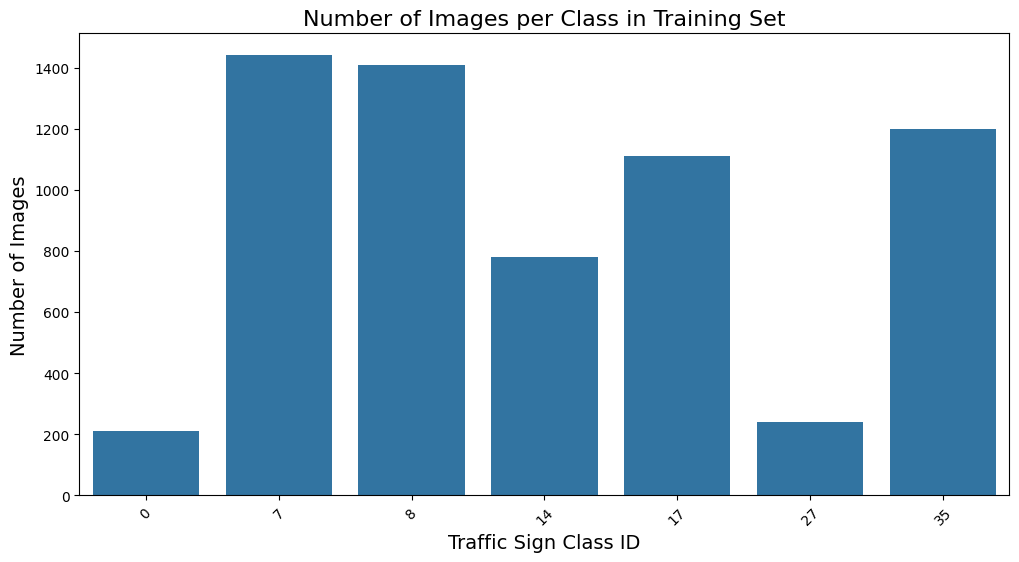

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='ClassId')
plt.title('Number of Images per Class in Training Set', fontsize=16)
plt.xlabel('Traffic Sign Class ID', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.xticks(rotation=45) 

plt.show()

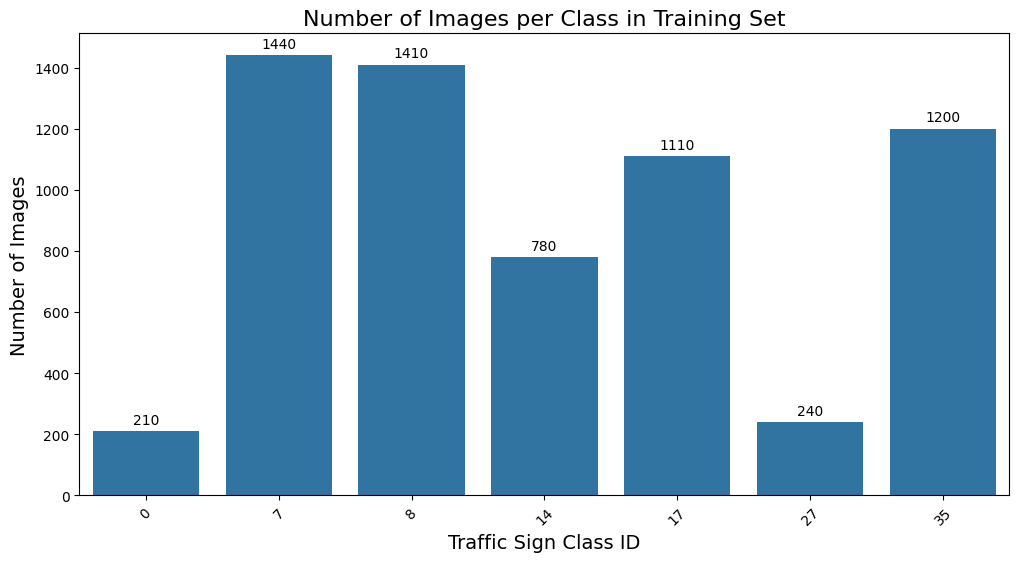

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))


ax = sns.countplot(data=df_train, x='ClassId')

for container in ax.containers:
    ax.bar_label(container, padding=3) 

plt.title('Number of Images per Class in Training Set', fontsize=16)
plt.xlabel('Traffic Sign Class ID', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)

plt.xticks(rotation=45) 
plt.show()

# There are a lot of way to deal with imbalance dataset, For now we keep it simple 

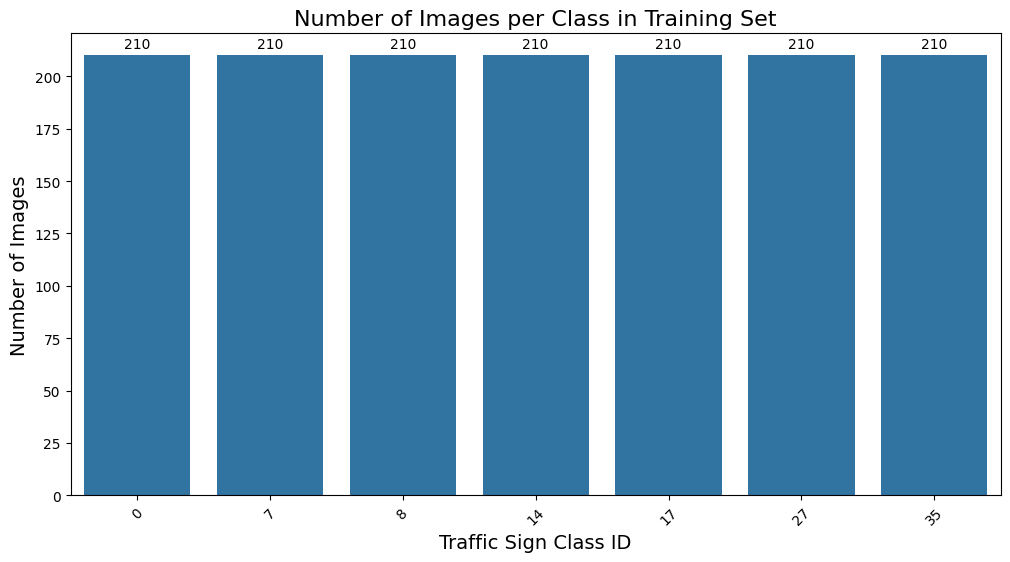

In [9]:
df_train_balanced = df_train.groupby('ClassId').sample(n=210, random_state=42)
df_train_balanced = df_train_balanced.reset_index(drop=True)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_train_balanced, x='ClassId')
for container in ax.containers:
    ax.bar_label(container, padding=3) 
plt.title('Number of Images per Class in Training Set', fontsize=16)
plt.xlabel('Traffic Sign Class ID', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)

plt.xticks(rotation=45) 
plt.show()

# Fine Tune The Model

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import time

class GTSRB_Dataset(Dataset):
    def __init__(self, dataframe, base_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.unique_classes = sorted(self.dataframe['ClassId'].unique())
        self.class_to_idx = {class_id: idx for idx, class_id in enumerate(self.unique_classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.base_dir, self.dataframe.loc[idx, 'Path'])
        image = Image.open(img_path).convert('RGB')
        
        original_class = self.dataframe.loc[idx, 'ClassId']
        label = self.class_to_idx[original_class]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [11]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(
    df_train_balanced, 
    test_size=0.2, 
    stratify=df_train_balanced['ClassId'], 
    random_state=42
)

print(f"Training samples: {len(df_train_split)}")
print(f"Validation samples: {len(df_val_split)}")


train_dataset = GTSRB_Dataset(dataframe=df_train_split, base_dir=dir_csv, transform=transform)
val_dataset = GTSRB_Dataset(dataframe=df_val_split, base_dir=dir_csv, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


Training samples: 1176
Validation samples: 294


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
num_classes = len(train_dataset.unique_classes)
model.fc = nn.Linear(num_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cuda


In [13]:
def top_k_accuracy(output, target, k=5):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)  # Get top-k predictions
    pred = pred.t()  # Transpose predictions for comparison
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))  # Compare predictions with target
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)  # Calculate correct top-k
    return correct_k.mul_(1.0 / batch_size).item()  # Calculate top-k accuracy

class BaseTrainer:
    def __init__(self, model, criterion, optimizer, train_loader, val_loader):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.stop_training = False

    def fit(self, num_epochs):
        self.num_batches = len(self.train_loader)
        for epoch in range(num_epochs):
            if self.stop_training:
                break
            print(f'Epoch {epoch + 1}/{num_epochs}')
            start_time = time.time()
            train_loss, train_accuracy = self.train_one_epoch()
            val_loss, top1_acc, top5_acc = self.validate_one_epoch()
            print(
                f' train_loss: {train_loss:.4f} - train_accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - top1_acc: {top1_acc:.4f} - top5_acc: {top5_acc:.4f}'
            )
            self.on_epoch_end({'epoch': epoch, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'val_loss': val_loss, 'val_accuracy': top1_acc, 'top5_acc': top5_acc})

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(self.train_loader, desc='Training', leave=False)
        for i, data in enumerate(pbar):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total
        train_loss = running_loss / self.num_batches
        return train_loss, train_accuracy

    def validate_one_epoch(self):
        self.model.eval()
        val_loss, correct, total_top1_acc, total_top5_acc, total = 0.0, 0, 0.0, 0.0, 0
        with torch.no_grad():
            for data in self.val_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()

                top1_acc = top_k_accuracy(outputs, labels, k=1)
                top5_acc = top_k_accuracy(outputs, labels, k=5)

                total_top1_acc += top1_acc * inputs.size(0)  # Custom evaluation metric
                total_top5_acc += top5_acc * inputs.size(0)  # Custom evaluation metric
                total += labels.size(0)

        val_loss /= len(self.val_loader)
        top1_acc = total_top1_acc / total
        top5_acc = total_top5_acc / total
        return val_loss, top1_acc, top5_acc

    def on_epoch_end(self, params):
        pass

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
trainer = BaseTrainer(model, criterion, optimizer, train_loader, val_loader)
trainer.fit(num_epochs=15)

Epoch 1/15


 train_loss: 1.0781 - train_accuracy: 0.6777 - val_loss: 0.3481 - top1_acc: 0.9082 - top5_acc: 1.0000
Epoch 2/15


 train_loss: 0.2408 - train_accuracy: 0.9481 - val_loss: 0.1251 - top1_acc: 0.9762 - top5_acc: 1.0000
Epoch 3/15


 train_loss: 0.1043 - train_accuracy: 0.9830 - val_loss: 0.0948 - top1_acc: 0.9830 - top5_acc: 1.0000
Epoch 4/15


 train_loss: 0.0571 - train_accuracy: 0.9957 - val_loss: 0.0851 - top1_acc: 0.9796 - top5_acc: 1.0000
Epoch 5/15


...

 train_loss: 0.0089 - train_accuracy: 1.0000 - val_loss: 0.0375 - top1_acc: 0.9898 - top5_acc: 1.0000
Epoch 12/15


 train_loss: 0.0080 - train_accuracy: 1.0000 - val_loss: 0.0197 - top1_acc: 0.9966 - top5_acc: 1.0000
Epoch 13/15


 train_loss: 0.0091 - train_accuracy: 0.9991 - val_loss: 0.0337 - top1_acc: 0.9898 - top5_acc: 1.0000
Epoch 14/15


 train_loss: 0.0064 - train_accuracy: 1.0000 - val_loss: 0.0234 - top1_acc: 0.9966 - top5_acc: 1.0000
Epoch 15/15


 train_loss: 0.0059 - train_accuracy: 1.0000 - val_loss: 0.0409 - top1_acc: 0.9898 - top5_acc: 1.0000


In [15]:
import numpy as np 
import pandas as pd
import os

dir_csv = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
df_test = pd.read_csv(os.path.join(dir_csv,"Test.csv"))
df_test= df_test[df_test['ClassId'].isin(Label)]
df_test.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
9,81,86,7,7,74,79,35,Test/00009.png
11,45,44,6,5,40,39,7,Test/00011.png
13,36,37,5,6,31,32,7,Test/00013.png
18,35,35,5,6,30,29,27,Test/00018.png
31,29,34,5,6,24,29,17,Test/00031.png


In [16]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

df_test = df_test.reset_index(drop=True)
test_dataset = GTSRB_Dataset(dataframe=df_test, base_dir=dir_csv, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='Testing', leave=True)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        # Move tensors to CPU and convert to numpy arrays for sklearn
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())



Testing: 100%|██████████| 64/64 [00:04<00:00, 13.50it/s]


================ PERFORMANCE REPORT ================
                       precision    recall  f1-score   support

 Speed limit (20km/h)     1.0000    0.7167    0.8350        60
Speed limit (100km/h)     0.9717    0.9911    0.9813       450
Speed limit (120km/h)     0.9541    0.9711    0.9626       450
                 Stop     0.9963    1.0000    0.9982       270
             No entry     1.0000    0.9972    0.9986       360
          Pedestrians     1.0000    1.0000    1.0000        60
           Ahead only     1.0000    1.0000    1.0000       390

             accuracy                         0.9828      2040
            macro avg     0.9889    0.9537    0.9679      2040
         weighted avg     0.9831    0.9828    0.9823      2040



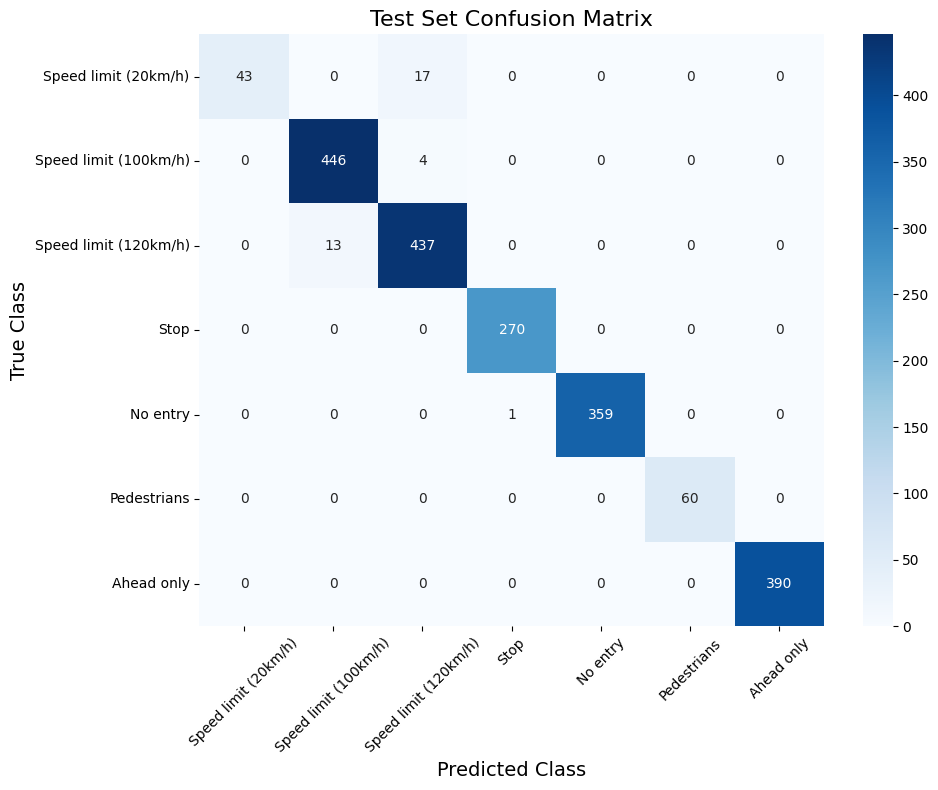

In [17]:
# 1. Map the continuous internal labels (0, 1, 2...) back to the original GTSRB ClassIds
# test_dataset.unique_classes contains the original ClassIds (e.g., 14, 17, 38)
target_names = [Label_name[cls_id] for cls_id in test_dataset.unique_classes]

# 2. Print the Classification Report
print("================ PERFORMANCE REPORT ================")
report = classification_report(all_targets, all_preds, target_names=target_names, digits=4)
print(report)

# 3. Plot the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
# 'fmt="d"' ensures the annotations are integers (raw counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Test Set Confusion Matrix', fontsize=16)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Attack the Model ( Using PGD Attack )

In [18]:
def pgd_attack(model, input_image, input_label=None,
               epsilon=0.0313,
               num_steps=20,
               step_size=0.002,
               clip_value_min=0.,
               clip_value_max=1.0):

    if type(input_image) is np.ndarray:
        input_image = torch.tensor(input_image, requires_grad=True)

    if type(input_label) is np.ndarray:
        input_label = torch.tensor(input_label)

    # Ensure the model is in evaluation mode
    model.eval()

    # Create a copy of the input image and set it to require gradients
    adv_image = input_image.clone().detach().requires_grad_(True)  # Ensure requires_grad is True

    # Random initialization around input_image
    random_noise = torch.FloatTensor(input_image.shape).uniform_(-epsilon, epsilon).to(device)
    adv_image = adv_image + random_noise
    adv_image = torch.clamp(adv_image, clip_value_min, clip_value_max).detach().requires_grad_(True)

    # If no input label is provided, use the model's prediction
    if input_label is None:
        output = model(input_image)
        input_label = torch.argmax(output, dim=1)

    # Perform PGD attack
    for _ in range(num_steps):
        adv_image.requires_grad_(True)  # Ensure requires_grad is True in each iteration
        output = model(adv_image)
        loss = nn.CrossEntropyLoss()(output, input_label)
        model.zero_grad()
        loss.backward()

        # Check if gradient is available before accessing 'data'
        if adv_image.grad is not None:
            gradient = adv_image.grad.data
            adv_image = adv_image + step_size * gradient.sign()
            adv_image = torch.clamp(adv_image, input_image - epsilon, input_image + epsilon)  # Clip to a valid boundary
            adv_image = torch.clamp(adv_image, clip_value_min, clip_value_max)  # Clip to a valid range
            adv_image = adv_image.detach()  # Detach to prevent gradient accumulation
        else:
            print("Warning: Gradient is None. Check for detach operations.")

    return adv_image.detach()

In [19]:
def pgd_attack_targeted(model, input_image, target_label=None,
               epsilon=0.0313,
               num_steps=20,
               step_size=0.002,
               clip_value_min=0.,
               clip_value_max=1.0):

    if type(input_image) is np.ndarray:
        input_image = torch.tensor(input_image, requires_grad=True)

    if type(target_label) is np.ndarray:
        input_label = torch.tensor(target_label)

    # Ensure the model is in evaluation mode
    model.eval()

    # Create a copy of the input image and set it to require gradients
    adv_image = input_image.clone().detach().requires_grad_(True)  # Ensure requires_grad is True

    # Random initialization around input_image
    random_noise = torch.FloatTensor(input_image.shape).uniform_(-epsilon, epsilon).to(device)
    adv_image = adv_image + random_noise
    adv_image = torch.clamp(adv_image, clip_value_min, clip_value_max).detach().requires_grad_(True)

    # If no input label is provided, use the model's prediction
    if target_label is None:
        output = model(input_image)
        target_label = torch.argmax(output, dim=1)

    # Perform PGD attack
    for _ in range(num_steps):
        adv_image.requires_grad_(True)  # Ensure requires_grad is True in each iteration
        output = model(adv_image)
        loss = nn.CrossEntropyLoss()(output, target_label)
        model.zero_grad()
        loss.backward()

        # Check if gradient is available before accessing 'data'
        if adv_image.grad is not None:
            gradient = adv_image.grad.data
            adv_image = adv_image - step_size * gradient.sign()
            adv_image = torch.clamp(adv_image, input_image - epsilon, input_image + epsilon)  # Clip to a valid boundary
            adv_image = torch.clamp(adv_image, clip_value_min, clip_value_max)  # Clip to a valid range
            adv_image = adv_image.detach()  # Detach to prevent gradient accumulation
        else:
            print("Warning: Gradient is None. Check for detach operations.")

    return adv_image.detach()

In [23]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

Label_name = gtsrb_classes = {
    0: 'Speed limit (20km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    14: 'Stop',
    17: 'No entry',
    27: 'Pedestrians',
    35: 'Ahead only'
}
'''
attack_mapping = {
    0: 7,
    7: 0,
    8: 8,
    14: 8,
    17: 35,
    27: 7,
    35: 35
}
'''
attack_mapping = {
    0: 1, # Force true label 0 (Class 0) to predict index 1 (Class 7)
    1: 0, # Force true label 1 (Class 7) to predict index 0 (Class 0)
    2: 2, # Force true label 2 (Class 8) to predict index 2 (Class 8)
    3: 2, # Force true label 3 (Class 14) to predict index 2 (Class 8)
    4: 6, # Force true label 4 (Class 17) to predict index 6 (Class 35)
    5: 1, # Force true label 5 (Class 27) to predict index 1 (Class 7)
    6: 6  # Force true label 6 (Class 35) to predict index 6 (Class 35)
}

model.eval()
loss_val_clean  = 0
loss_val_attack = 0
model.to(device)

all_true_labels = []
all_target_labels = []
all_clean_preds = []
all_attack_preds = []

predicted_right_clean = 0
predicted_right_attack = 0
total = 0 

softmax = nn.Softmax()
loss_fn = nn.CrossEntropyLoss()


for idx , (image , label) in enumerate(val_loader):
    image = image.to(device)
    label = label.to(device)
    mapped_labels = [attack_mapping.get(l.item(), l.item()) for l in label]
    target_labels_tensor = torch.tensor(mapped_labels, dtype=torch.long, device=device)
    # Loss Report
    x_pgd = pgd_attack_targeted(
        model=model, 
        input_image=image, 
        target_label=target_labels_tensor, # Using mapped labels here
        epsilon=0.0313, 
        num_steps=20, 
        step_size=0.02
    )
    

    with torch.no_grad():
        output_clean = model(image)
        output_attack = model(x_pgd)
        loss_fn
        running_loss_clean = loss_fn(output_clean,label)
        running_loss_attack = loss_fn(output_attack,label)

        loss_val_clean += running_loss_clean
        loss_val_attack += running_loss_attack

        # Clean Accurary Report
        _, predicted_clean = torch.max(output_clean.data, 1)
        predicted_right_clean += (predicted_clean == label).sum().item()
        total += label.size(0)
        
        # Attacked Accurary Report
        _, predicted_attacked = torch.max(output_attack.data, 1)
        predicted_right_attack += (predicted_attacked == label).sum().item()

        all_true_labels.extend(label.cpu().numpy())
        all_target_labels.extend(target_labels_tensor.cpu().numpy())
        all_clean_preds.extend(predicted_clean.cpu().numpy())
        all_attack_preds.extend(predicted_attacked.cpu().numpy())


loss_val_clean = loss_val_clean / (idx+1)
loss_val_attack = loss_val_attack / (idx+1)
acc_clean = predicted_right_clean/total
acc_attack = predicted_right_attack/total

print("Model Attack Report")
print("===========================================================================================")
print(f"Accuracy Before Attack {acc_clean*100:.2f}%")
print(f"Accuracy After Attack {acc_attack*100:.2f}%")
print(' ')
print(f"Loss Before Attack {loss_val_clean:.4f}")
print(f"Loss After Attack {loss_val_attack:.4f}")

Model Attack Report
Accuracy Before Attack 98.98%
Accuracy After Attack 26.87%
 
Loss Before Attack 0.0409
Loss After Attack 2.7853


                       MODEL ATTACK REPORT                            
Accuracy Before Attack:  98.98%
Accuracy After Attack:   26.87%
Loss Before Attack:      0.0409
Loss After Attack:       2.7853
----------------------------------------------------------------------
Targeted Attack Success Rate (ASR): 66.67%


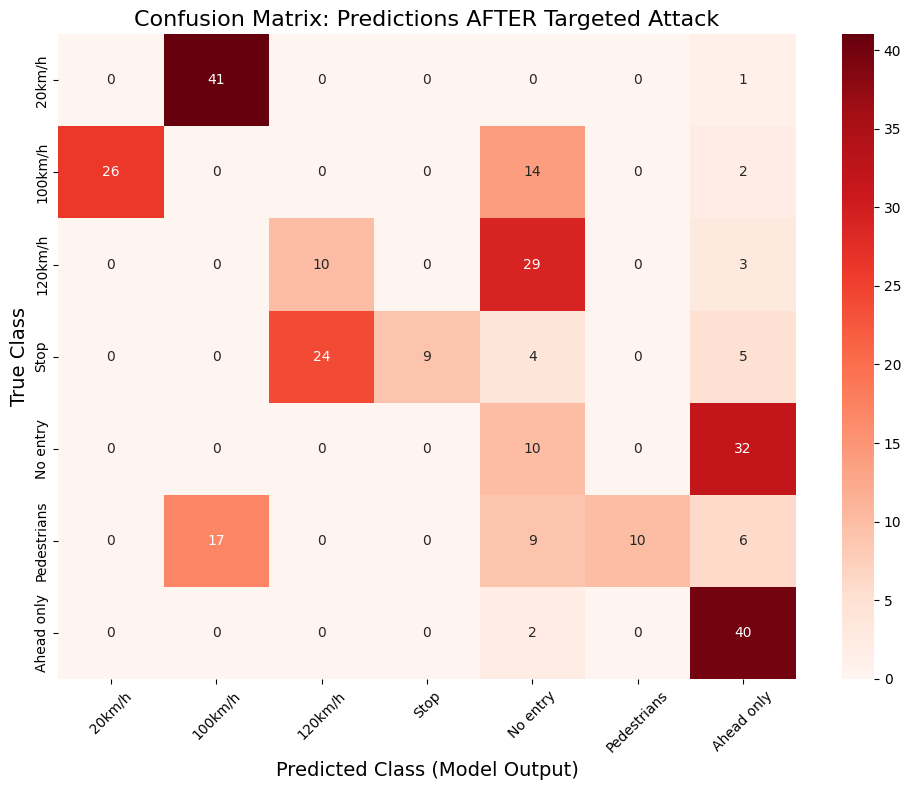

In [24]:
# Convert lists to numpy arrays for easy math
true_arr = np.array(all_true_labels)
target_arr = np.array(all_target_labels)
clean_preds_arr = np.array(all_clean_preds)
attack_preds_arr = np.array(all_attack_preds)

# 1. Calculate Standard Accuracies
acc_clean = (clean_preds_arr == true_arr).mean()
acc_attack = (attack_preds_arr == true_arr).mean()

# 2. Calculate Targeted Attack Success Rate (ASR)
# ASR is the percentage of time the model predicted your TARGET label, 
# but ONLY for the images where the target label is actually different from the true label.
attack_attempted_mask = (true_arr != target_arr)

if attack_attempted_mask.sum() > 0:
    successful_attacks = (attack_preds_arr[attack_attempted_mask] == target_arr[attack_attempted_mask])
    asr = successful_attacks.mean()
else:
    asr = 0.0 # Fallback if no attacks were mapped

print("======================================================================")
print("                       MODEL ATTACK REPORT                            ")
print("======================================================================")
print(f"Accuracy Before Attack:  {acc_clean*100:.2f}%")
print(f"Accuracy After Attack:   {acc_attack*100:.2f}%")
print(f"Loss Before Attack:      {loss_val_clean:.4f}")
print(f"Loss After Attack:       {loss_val_attack:.4f}")
print("----------------------------------------------------------------------")
print(f"Targeted Attack Success Rate (ASR): {asr*100:.2f}%")
print("======================================================================")

# 3. Plot the Attacked Confusion Matrix
# Map the 0-6 indices back to their string names for the chart
class_names = ['20km/h', '100km/h', '120km/h', 'Stop', 'No entry', 'Pedestrians', 'Ahead only']

plt.figure(figsize=(10, 8))
cm_attack = confusion_matrix(true_arr, attack_preds_arr)

# Plotting the heatmap
sns.heatmap(cm_attack, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: Predictions AFTER Targeted Attack', fontsize=16)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class (Model Output)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()